In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from gensim.models import Doc2Vec
from gensim.models.doc2vec import TaggedDocument
import umap
from spacy.lang.en import English
nlp = English(pipeline=[])
nlp.add_pipe("sentencizer")
from gensim import corpora

In [38]:
tweets_df = pd.read_csv("data/trump_tweets.csv")

tweets_df["date"] = pd.to_datetime(tweets_df["date"])
tweets_df["isPresident"] = (
    tweets_df["date"].between(pd.to_datetime("2017-1-20"), pd.to_datetime("2021-1-20"))
) | (
    tweets_df["date"] > pd.to_datetime("2025-1-20")
)  # YMD format

tweets_df = tweets_df.sort_values(by="date")

# ---------------------------------------------------------------

obama_tweets_df = pd.read_csv("data/obama.csv")
obama_tweets_df["date"] = pd.to_datetime(obama_tweets_df["Timestamp"]).dt.tz_localize(
    None
)
obama_tweets_df["isPresident"] = obama_tweets_df["date"].between(
    pd.to_datetime("2009-1-20"), pd.to_datetime("2017-1-20")
)  # YMD format

obama_tweets_df = obama_tweets_df.sort_values(by="date")
obama_tweets_df.drop("Emojis", axis=1, inplace=True)

# ---------------------------------------------------------------

vix_df = pd.read_csv("data/VIX_DAILY.csv")
vix_df["observation_date"] = pd.to_datetime(vix_df["observation_date"])
returns = np.array(np.log(vix_df["VIXCLS"])[1:-1]) - np.array(
    np.log(vix_df["VIXCLS"])[:-2]
)
vix_df["return"] = np.pad(returns, (0, 2), mode="constant")  # add 0's at the end
vix_df["absreturn"] = np.abs(vix_df["return"])

vix_df = vix_df.sort_values("observation_date")

merged = pd.merge_asof(
    tweets_df, vix_df, left_on="date", right_on="observation_date", direction="backward"
)
merged.dropna(inplace=True)
merged_bama = pd.merge_asof(
    obama_tweets_df,
    vix_df,
    left_on="date",
    right_on="observation_date",
    direction="backward",
)
merged_bama.dropna(inplace=True)

In [41]:
def tokenize(tweet):
    doc = nlp(str(tweet))
    tokens = []
    for sent in doc.sents:
        for token in sent:
            if not token.is_space:
                tokens.append(token.text.lower().strip())
        #print(sent)
    return tokens

In [ ]:
# Tokenize Data for Doc2Vec

trump_docs = [
    TaggedDocument(tokenize(doc), tags=[str(i)])
    for i, doc in enumerate(merged[merged["isPresident"]]["text"])
]
obama_docs = [
    TaggedDocument(tokenize(doc), tags=[str(i)])
    for i, doc in enumerate(merged_bama[merged_bama["isPresident"]]["Embedded_text"])
]

In [144]:
# Doc2Vec Model

vsize = 300 # Tried a bunch of different values
trump_space = Doc2Vec(trump_docs, min_count=5, epochs=5, vector_size=vsize)
obama_space = Doc2Vec(obama_docs, min_count=5, epochs=5, vector_size=vsize)

In [184]:
# Generate BOW embeddings

trump_dict = corpora.Dictionary()

trump_bow = [
    trump_dict.doc2bow(tokenize(doc), allow_update=True)
    for doc in merged[merged["isPresident"]]["text"]
]

obama_dict = corpora.Dictionary()

obama_bow = [
    obama_dict.doc2bow(tokenize(doc), allow_update=True)
    for doc in merged_bama[merged_bama["isPresident"]]["Embedded_text"]
]

In [205]:
# Format BOW embeddings for UMAP

new_embeddings = []
for doc_embeddings in [trump_bow, obama_bow]:
    end = max([max(i) for i in doc_embeddings])[0] + 1
    new_bow = []
    for doc in doc_embeddings:
        bow = np.zeros([end])
        for word in doc:
            bow[word[0]] = word[1]
        new_bow.append(bow)
    new_embeddings.append(new_bow)


trump_bow_embeddings = np.array(new_embeddings[0])
obama_bow_embeddings = np.array(new_embeddings[1])

In [137]:
trump_arr = np.array([trump_space.dv[id] for id in trump_space.dv.index_to_key])
obama_arr = np.array([obama_space.dv[id] for id in obama_space.dv.index_to_key])

In [138]:
reducer = umap.UMAP(n_components=2)
obama_small = reducer.fit_transform(obama_arr)

reducer = umap.UMAP(n_components=2)
trump_small = reducer.fit_transform(trump_arr)

In [139]:
ldim_obama = pd.DataFrame(obama_small, columns=["x", "y"])
ldim_obama["VIX"] = merged_bama["VIXCLS"][merged_bama["isPresident"]]

ldim_trump = pd.DataFrame(trump_small, columns=["x", "y"])
ldim_trump["VIX"] = np.array(merged["VIXCLS"][merged["isPresident"]])

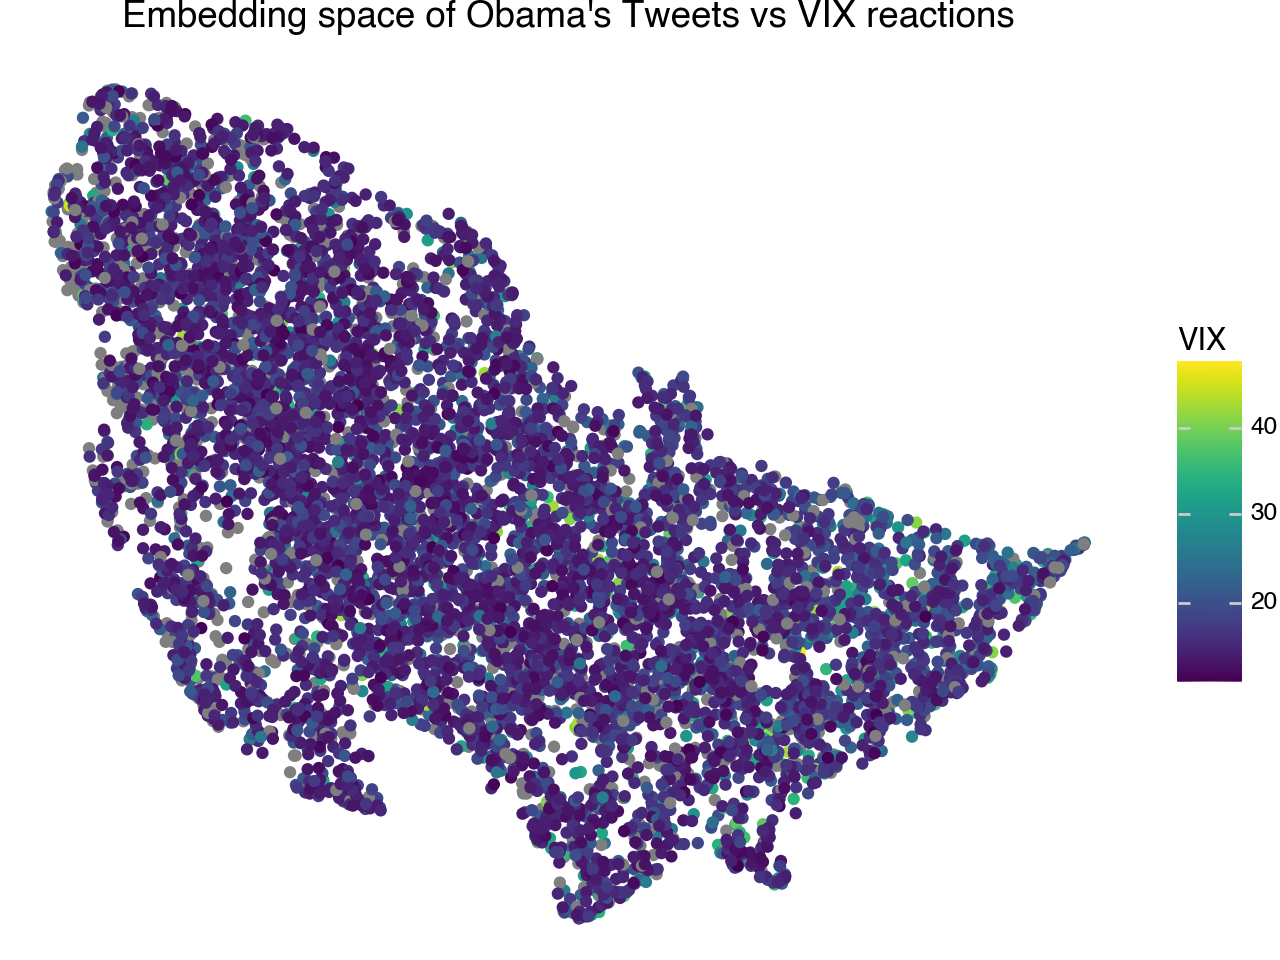

In [140]:
from plotnine import ggplot, aes, geom_point, theme_void, labs

(ggplot(ldim_obama, aes(x="x", y="y", color="VIX")) + 
 geom_point() + 
 labs(title="Embedding space of Obama's Tweets vs VIX reactions") + 
 theme_void())

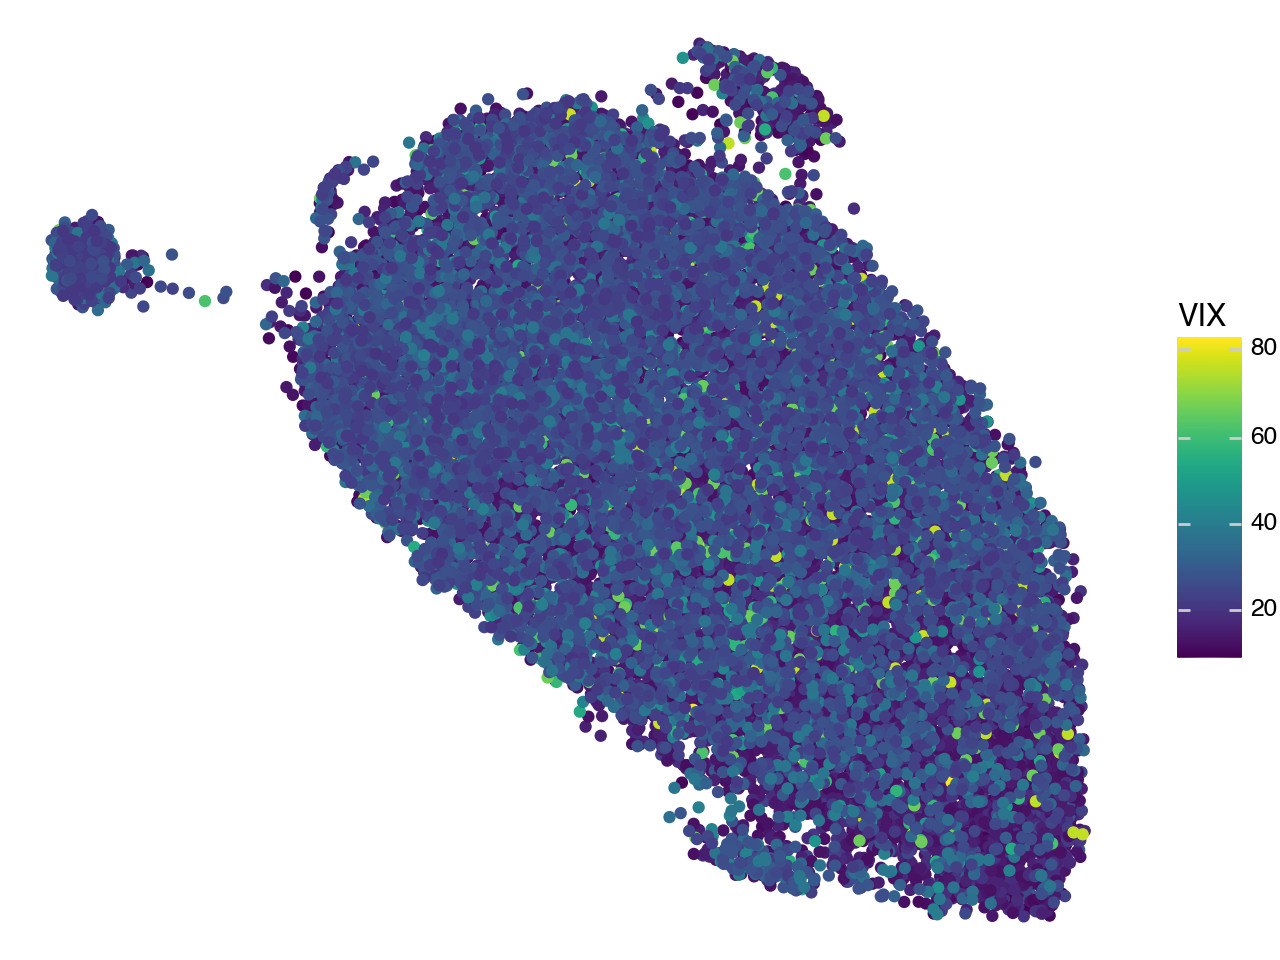

In [141]:
(ggplot(ldim_trump, aes(x="x", y="y", color="VIX")) + 
 geom_point() + 
 theme_void())